# Notebook 03 â€” Model Analysis & Anomaly Visualisation
Load trained checkpoint, score images, inspect heatmaps, plot ROC/PR curves.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('.').resolve()))

import json
import numpy as np
import torch
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cpu


In [2]:
# â”€â”€ Load model â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
from vae import ConvVAE

model = ConvVAE(latent_dim=256)
ckpt_path = Path('./checkpoints/best_vae.pth')

if ckpt_path.exists():
    ckpt = torch.load(str(ckpt_path), map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['state'])
    model.to(DEVICE).eval()
    print(f'Loaded checkpoint â€” epoch {ckpt["epoch"]},  val_loss={ckpt["val_loss"]:.5f}')
else:
    print(f'Checkpoint not found at {ckpt_path}')
    print('Run:  python scripts/train.py  first.')

Loaded checkpoint â€” epoch 1,  val_loss=1.42002


In [3]:
# â”€â”€ Build DataLoader â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
from dataset import build_dataloaders

_, _, test_loader = build_dataloaders(
    records_file=Path('./data/normalized/normalization_records.json'),
    batch_size=32,
    num_workers=0,   # 0 for notebooks
)
print(f'Test batches: {len(test_loader)}')

c:\Users\P.V.H.Shanmukha\OneDrive\Documents\project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  Dataset split — train: 307 | val: 38 | test: 39
Test batches: 2


c:\Users\P.V.H.Shanmukha\OneDrive\Documents\project\venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
C:\Users\P.V.H.Shanmukha\OneDrive\Documents\project\augmentation.py:32: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(2.0, 12.0), p=0.3),
C:\Users\P.V.H.Shanmukha\OneDrive\Documents\project\augmentation.py:34: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(


In [5]:
# â”€â”€ Score all test images â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
from tqdm import tqdm

scores = []
with torch.no_grad():
    for batch in tqdm(test_loader, desc='Scoring'):
        x = batch.to(DEVICE)
        s = model.anomaly_score(x).cpu().numpy()
        scores.extend(s.tolist())

scores = np.array(scores)
print(f'Scores â€” mean: {scores.mean():.5f}  std: {scores.std():.5f}')
print(f'         min:  {scores.min():.5f}  max: {scores.max():.5f}')

c:\Users\P.V.H.Shanmukha\OneDrive\Documents\project\venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Scoring: 100%|██████████| 2/2 [00:00<00:00,  4.17it/s]

Scores â€” mean: 1.07909  std: 0.08793
         min:  0.92760  max: 1.28060


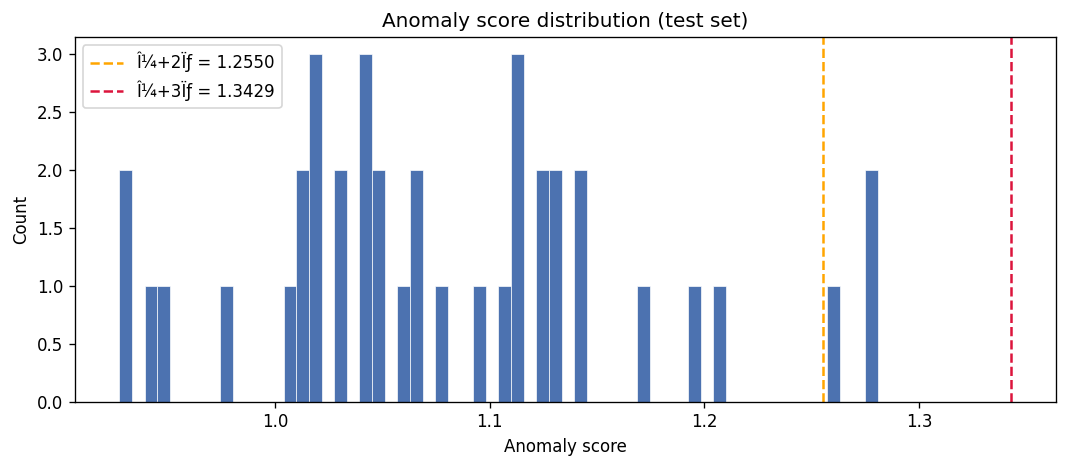

Flagged anomalous (Î¼+2Ïƒ): 3 / 39


In [6]:
# â”€â”€ Score distribution â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
thresh_2sig = scores.mean() + 2 * scores.std()
thresh_3sig = scores.mean() + 3 * scores.std()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(scores, bins=60, color='#4C72B0', edgecolor='white', linewidth=0.4)
ax.axvline(thresh_2sig, color='orange', linestyle='--', linewidth=1.5, label=f'Î¼+2Ïƒ = {thresh_2sig:.4f}')
ax.axvline(thresh_3sig, color='crimson', linestyle='--', linewidth=1.5, label=f'Î¼+3Ïƒ = {thresh_3sig:.4f}')
ax.set_xlabel('Anomaly score'); ax.set_ylabel('Count')
ax.set_title('Anomaly score distribution (test set)')
ax.legend(); plt.tight_layout(); plt.show()

print(f'Flagged anomalous (Î¼+2Ïƒ): {(scores > thresh_2sig).sum()} / {len(scores)}')

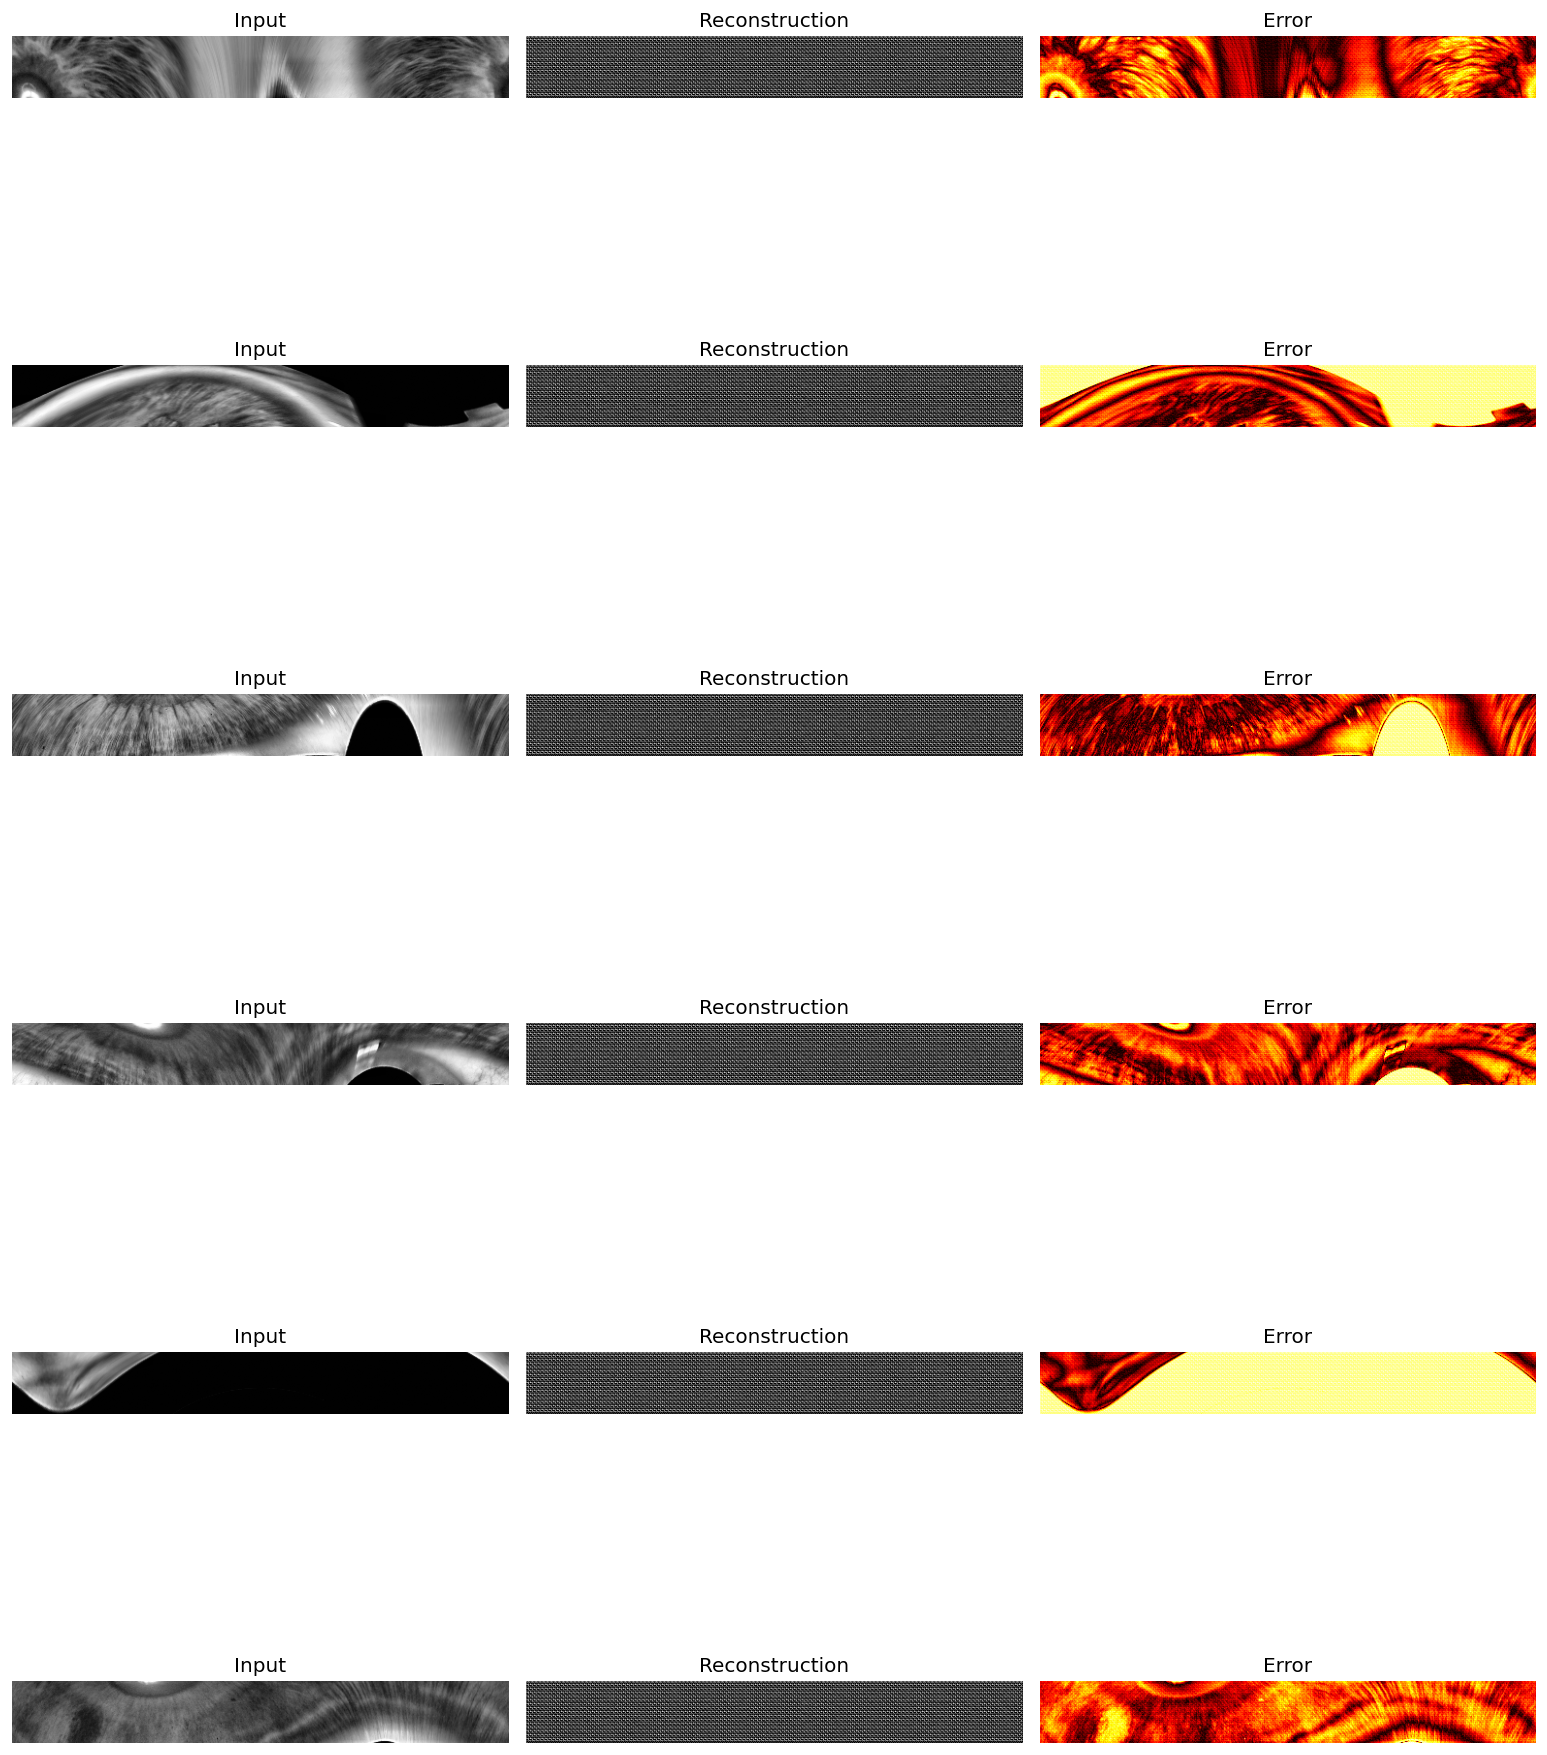

In [7]:
# Make sure test_loader exists
batch = next(iter(test_loader))
batch = batch[:6].to(DEVICE)

with torch.no_grad():
    recon, mu, logvar = model(batch)

fig, axes = plt.subplots(6, 3, figsize=(13, 18))

for i in range(6):
    inp = batch[i, 0].cpu().numpy()
    rec = recon[i, 0].cpu().numpy()
    err = np.abs(inp - rec)

    axes[i, 0].imshow(inp, cmap='gray')
    axes[i, 0].set_title('Input')

    axes[i, 1].imshow(rec, cmap='gray')
    axes[i, 1].set_title('Reconstruction')

    axes[i, 2].imshow(err, cmap='hot')
    axes[i, 2].set_title('Error')

    for ax in axes[i]:
        ax.axis('off')

plt.tight_layout()
plt.show()

c:\Users\P.V.H.Shanmukha\OneDrive\Documents\project\venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Running t-SNE â€¦


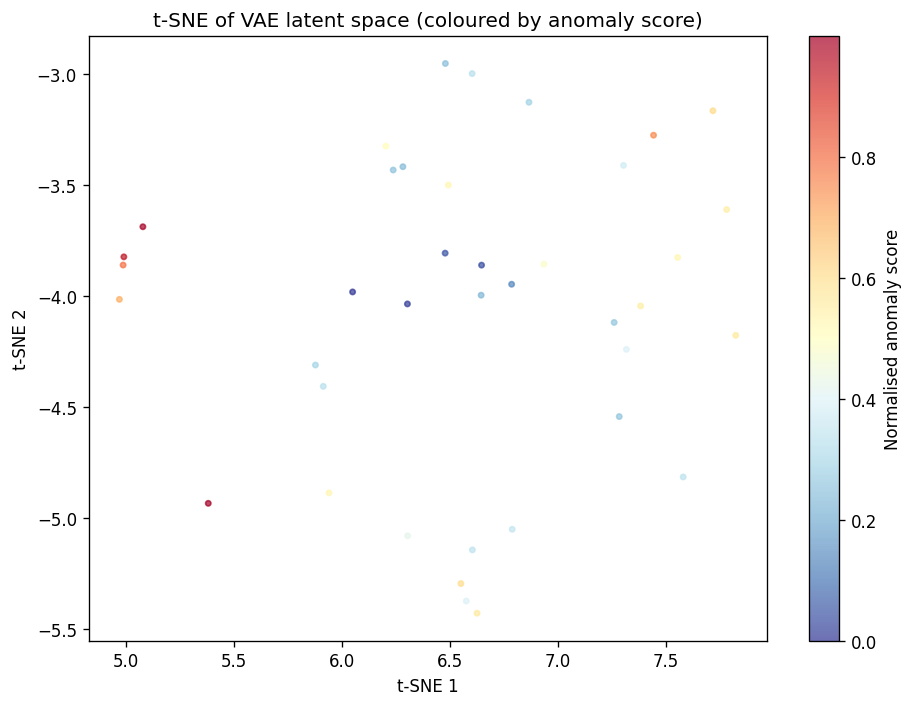

In [8]:
# â”€â”€ Latent space t-SNE â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
from sklearn.manifold import TSNE

latent_vecs = []
with torch.no_grad():
    for batch in test_loader:
        x = batch.to(DEVICE)
        mu, _ = model.encode(x)
        latent_vecs.append(mu.cpu().numpy())

Z = np.concatenate(latent_vecs)
# Colour by anomaly score
score_colors = (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)

print('Running t-SNE â€¦')
tsne   = TSNE(n_components=2, random_state=42, perplexity=30)
Z_2d   = tsne.fit_transform(Z[:min(len(Z), 500)])   # limit for speed
colors = score_colors[:len(Z_2d)]

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(Z_2d[:, 0], Z_2d[:, 1], c=colors, cmap='RdYlBu_r',
                s=10, alpha=0.7)
plt.colorbar(sc, ax=ax, label='Normalised anomaly score')
ax.set_title('t-SNE of VAE latent space (coloured by anomaly score)')
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
plt.tight_layout(); plt.show()